# Tarea 3: Funciones, Modelos personalizados y Ecuaciones Diferenciales

### **1. Capa personalizada**: RGB a escala de grises

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
#Definimos Capa
class CapaEscalaGrises(keras.layers.Layer):

    def call(self, inputs):
        inputs = tf.cast(inputs, tf.float32)
        return tf.image.rgb_to_grayscale(inputs)

In [3]:
#Probamos
(x_color, y_color), (x_test_color, y_test_color) = keras.datasets.cifar10.load_data()

print("Forma de las imágenes:", x_color.shape)
print("Forma de una imagen:", x_color[0].shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1559s 9us/step
Forma de las imágenes: (50000, 32, 32, 3)
Forma de una imagen: (32, 32, 3)


In [4]:
modelo_gris = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
    CapaEscalaGrises()
])

modelo_gris.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_escala_grises              │ (None, 32, 32, 1)      │             0 │
│ (CapaEscalaGrises)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Probamos una imagen
imagen_color = x_color[10]

imagen_gris = modelo_gris.predict(
    np.expand_dims(imagen_color, axis=0),
    verbose=0
)[0]

print("Imagen original:", imagen_color.shape)
print("Imagen en gris:", imagen_gris.shape)

Imagen original: (32, 32, 3)
Imagen en gris: (32, 32, 1)


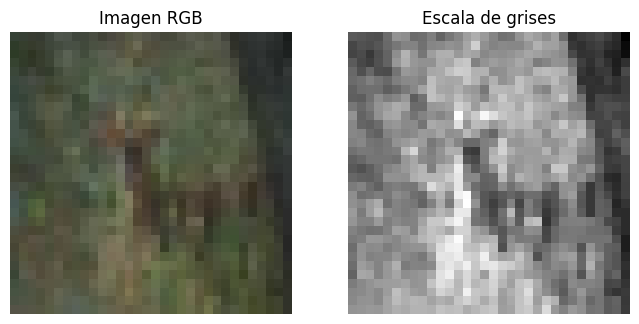

In [6]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(imagen_color)
plt.title("Imagen RGB")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(imagen_gris.squeeze(), cmap="gray")
plt.title("Escala de grises")
plt.axis("off")

plt.show()

La capa personalizada transforma una imagen RGB de tres canales a una representación de un canal en escala de grises. Debido a que la transformación no contiene parámetros ajustables, la capa no requiere entrenamiento y posee cero parámetros entrenables.

### **2. Redes neuronales para aproximar funciones**

In [7]:
def crear_red_funcion():
    modelo = keras.Sequential([
        keras.Input(shape=(1,)),
        layers.Dense(64, activation="tanh"),
        layers.Dense(64, activation="tanh"),
        layers.Dense(64, activation="tanh"),
        layers.Dense(1)
    ])
# Usamos tanh porque estamos aproximando funciones continuas y suaves

    modelo.compile(
        optimizer=Adam(learning_rate=0.01),
        loss="mse"
    )

    return modelo

 a) $3sin(\pi x)$

In [8]:
#Generamos puntos en [-1,1]
x = np.linspace(-1, 1, 1000, dtype=np.float32).reshape(-1, 1)

y = 3 * np.sin(np.pi * x)

print(x.shape)
print(y.shape)

(1000, 1)
(1000, 1)


In [9]:
indices = np.random.permutation(len(x))

x_train = x[indices]
y_train = y[indices]

In [10]:
#Entrenamiento
modelo_2a = crear_red_funcion()

historia_2a = modelo_2a.fit(
    x_train,
    y_train,
    epochs=1000,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)

In [11]:
#Evaluacion sobre una malla mas fina
x_graf = np.linspace(-1, 1, 1000, dtype=np.float32).reshape(-1, 1)

y_real = 3 * np.sin(np.pi * x_graf)
y_red = modelo_2a.predict(x_graf, verbose=0)

rmse_2a = np.sqrt(np.mean((y_real - y_red)**2))

print("RMSE:", rmse_2a)

RMSE: 0.022795878


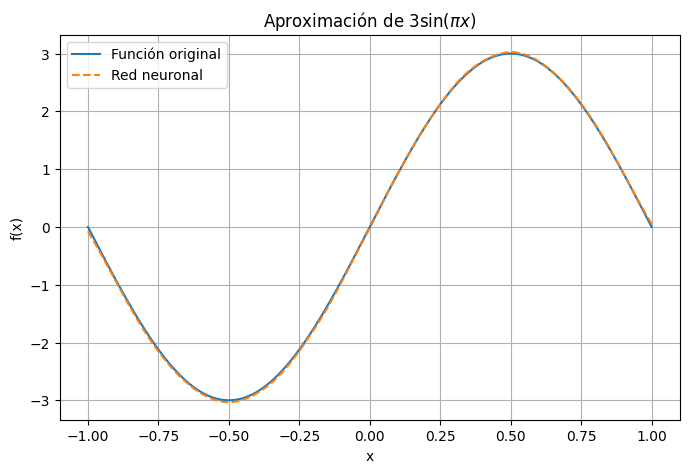

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    x_graf,
    y_real,
    label="Función original"
)

plt.plot(
    x_graf,
    y_red,
    "--",
    label="Red neuronal"
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"Aproximación de $3\sin(\pi x)$")
plt.legend()
plt.grid()
plt.show()

2b)$ 1+2x+4x^3$

In [72]:
# Generar datos sintéticos para el entrenamiento
x_2b = np.linspace(-1, 1, 2000).reshape(-1, 1)

# Función original
y_2b = 1 + 2*x_2b + 4*(x_2b**3)

In [65]:
# Diseñar la arquitectura de la Red Neuronal
model = tf.keras.Sequential([
    # Capa de entrada implícita en la primera capa oculta (1 valor: x)
    tf.keras.layers.Dense(64, activation='relu', input_shape=(1,)),
    # Segunda capa oculta para capturar mayor complejidad estructural
    tf.keras.layers.Dense(32, activation='relu'),
    # Capa de salida (1 valor numérico: f(x)). Sin activación para regresión pura
    tf.keras.layers.Dense(1)
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [66]:
# Compilar el modelo
# Usamos el optimizador Adam y el Error Cuadrático Medio (MSE) como función de pérdida
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss='mean_squared_error')

In [67]:
# Entrenar el modelo
print("Entrenando la red neuronal...")
history = model.fit(x_2b, y_2b, epochs=150, batch_size=32, verbose=0)
print("¡Entrenamiento completado!")


Entrenando la red neuronal...
¡Entrenamiento completado!


In [73]:
# Evaluación
X_test = np.linspace(-1, 1, 100).reshape(-1, 1)  # Incluye un rango ligeramente más amplio
y_real = 1 + 2*X_test + 4*(X_test**3)
y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [75]:
rmse_2b = np.sqrt(
    np.mean((y_real - y_pred)**2)
)

print("RMSE:", rmse_2b)

RMSE: 0.010523478607845247


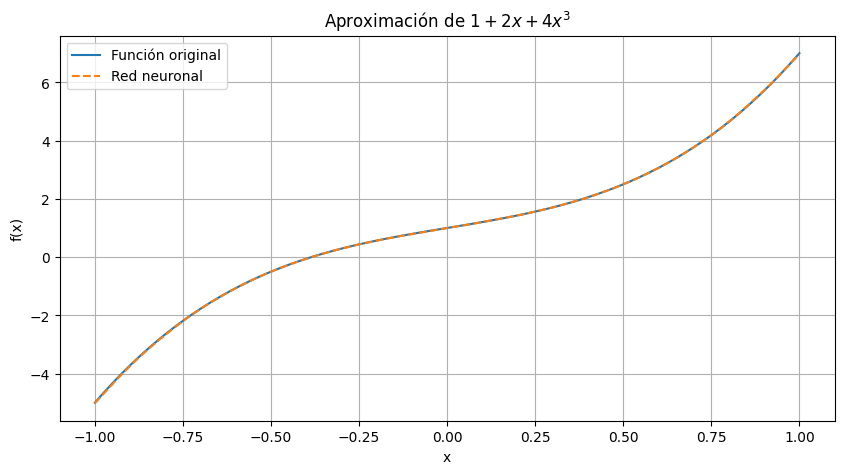

In [74]:

plt.figure(figsize=(10, 5))
plt.plot(X_test, y_real, label="Función original")
plt.plot(X_test, y_pred,"--", label="Red neuronal")
plt.title('Aproximación de Función Cúbica mediante Red Neuronal')
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"Aproximación de $1+2x+4x^3$")
plt.legend()
plt.grid()
plt.show()

### **3. Capa entrenable que representa un polinomio grado 3**

Función objetivo:
$$f(x) = a_0+a_1x+a_2x^2+a_3x^3$$
Parametros entrenables:
$$a_0,a_1,a_2,a_3$$

In [17]:
class PolinomioGrado3(keras.layers.Layer):

    def build(self, input_shape):

        self.a0 = self.add_weight(
            name="a0",
            shape=(),
            initializer="zeros",
            trainable=True
        )

        self.a1 = self.add_weight(
            name="a1",
            shape=(),
            initializer="zeros",
            trainable=True
        )

        self.a2 = self.add_weight(
            name="a2",
            shape=(),
            initializer="zeros",
            trainable=True
        )

        self.a3 = self.add_weight(
            name="a3",
            shape=(),
            initializer="zeros",
            trainable=True
        )

    def call(self, x):

        return (
            self.a0
            + self.a1 * x
            + self.a2 * x**2
            + self.a3 * x**3
        )

In [18]:
#Modelo
modelo_3 = keras.Sequential([
    keras.Input(shape=(1,)),
    PolinomioGrado3()
])

modelo_3.compile(
    optimizer=Adam(learning_rate=0.05),
    loss="mse"
)

modelo_3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ polinomio_grado3                │ (None, 1)              │             4 │
│ (PolinomioGrado3)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

Ahora ajustaremos la capa a la función $$f(x)=cos(2x)$$
en el intervalo $[-1,1]$

In [19]:
x = np.linspace(-1, 1, 1000, dtype=np.float32).reshape(-1, 1)

y = np.cos(2*x)

In [20]:
#Entrenamiento
historia_3 = modelo_3.fit(
    x,
    y,
    epochs=2000,
    batch_size=64,
    verbose=0
)

In [21]:
#Recuperamos coeficientes
capa_polinomio = modelo_3.layers[0]

print("a0 =", capa_polinomio.a0.numpy())
print("a1 =", capa_polinomio.a1.numpy())
print("a2 =", capa_polinomio.a2.numpy())
print("a3 =", capa_polinomio.a3.numpy())

a0 = 0.94732374
a1 = -0.013673466
a2 = -1.4955221
a3 = -0.015565476


In [22]:
x_graf = np.linspace(-1, 1, 1000, dtype=np.float32).reshape(-1, 1)

y_real = np.cos(2*x_graf)
y_red = modelo_3.predict(x_graf, verbose=0)

rmse_3 = np.sqrt(np.mean((y_real - y_red)**2))

print("RMSE:", rmse_3)

RMSE: 0.044981405


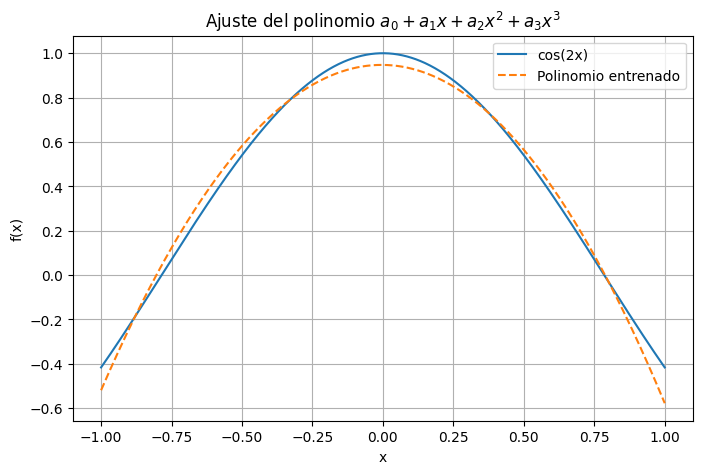

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    x_graf,
    y_real,
    label="cos(2x)"
)

plt.plot(
    x_graf,
    y_red,
    "--",
    label="Polinomio entrenado"
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"Ajuste del polinomio $a_0+a_1x+a_2x^2+a_3x^3$")
plt.legend()
plt.grid()
plt.show()

### **4. Ecuaciones diferenciales**

In [24]:
def crear_red_ode():

    modelo = keras.Sequential([
        keras.Input(shape=(1,)),
        layers.Dense(64, activation="tanh"),
        layers.Dense(64, activation="tanh"),
        layers.Dense(64, activation="tanh"),
        layers.Dense(1)
    ])

    return modelo

4a) $xy'+y=x^2cosx$, con $y(0)=0$

In [25]:
def solucion_4a(x):

    x = np.asarray(x, dtype=float)

    y = np.zeros_like(x)

    mascara = np.abs(x) > 1e-8

    y[mascara] = (
        x[mascara] * np.sin(x[mascara])
        + 2*np.cos(x[mascara])
        - 2*np.sin(x[mascara]) / x[mascara]
    )

    y[~mascara] = 0.0

    return y

In [26]:
def y_red_4a(modelo, x):
    return x**2 * modelo(x)

In [27]:
def residuo_4a(modelo, x):

    with tf.GradientTape() as tape:

        tape.watch(x)

        y = y_red_4a(modelo, x)

    dy_dx = tape.gradient(y, x)

    residuo = (
        x * dy_dx
        + y
        - x**2 * tf.cos(x)
    )

    return residuo

In [28]:
#Entrenamiento
def entrenar_4a(epochs=3000, n_puntos=1000):

    modelo = crear_red_ode()

    optimizador = Adam(learning_rate=0.001)

    x_col = tf.linspace(-5.0, 5.0, n_puntos)
    x_col = tf.reshape(x_col, (-1, 1))

    historial = []

    for epoch in range(epochs):

        with tf.GradientTape() as tape:

            residuo = residuo_4a(
                modelo,
                x_col
            )

            loss = tf.reduce_mean(
                tf.square(residuo)
            )

        gradientes = tape.gradient(
            loss,
            modelo.trainable_variables
        )

        optimizador.apply_gradients(
            zip(
                gradientes,
                modelo.trainable_variables
            )
        )

        historial.append(loss.numpy())

        if epoch % 500 == 0:
            print(
                f"Epoch {epoch}: Loss = {loss.numpy():.8f}"
            )

    return modelo, historial

In [29]:
modelo_4a, historia_4a = entrenar_4a()

Epoch 0: Loss = 525.56964111
Epoch 500: Loss = 0.57602799
Epoch 1000: Loss = 0.06488423
Epoch 1500: Loss = 0.02134837
Epoch 2000: Loss = 0.01300479
Epoch 2500: Loss = 0.00611002


 **Solución Numérica vs Analítica**

In [30]:
x_graf = np.linspace(
    -5,
    5,
    1500,
    dtype=np.float32
).reshape(-1, 1)

y_analitica = solucion_4a(
    x_graf.flatten()
)

y_numerica = y_red_4a(
    modelo_4a,
    tf.constant(x_graf)
).numpy().flatten()

In [31]:
#Calculamos el error
rmse_4a = np.sqrt(
    np.mean(
        (y_analitica - y_numerica)**2
    )
)

max_error_4a = np.max(
    np.abs(y_analitica - y_numerica)
)

print("RMSE:", rmse_4a)
print("Error máximo:", max_error_4a)

RMSE: 0.023136337110810774
Error máximo: 0.062326730945211795


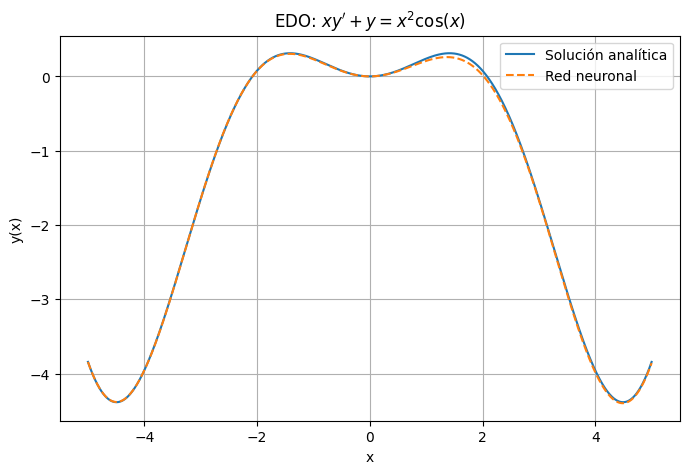

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    x_graf,
    y_analitica,
    label="Solución analítica"
)

plt.plot(
    x_graf,
    y_numerica,
    "--",
    label="Red neuronal"
)

plt.xlabel("x")
plt.ylabel("y(x)")
plt.title(r"EDO: $xy'+y=x^2\cos(x)$")
plt.legend()
plt.grid()
plt.show()

Podemos notar que la pérdida bajó

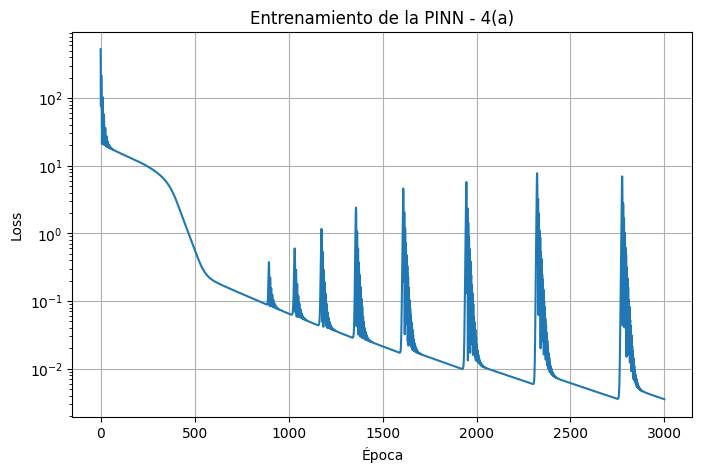

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(historia_4a)

plt.yscale("log")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Entrenamiento de la PINN - 4(a)")
plt.grid()
plt.show()

4b)$ \frac{d^2y}{dx^2}=-y$ con $y(0)=1, y'(0)=-0.5$

In [34]:
#Condiciones iniciales
def y_red_4b(modelo, x):

    return (
        1
        - 0.5*x
        + x**2 * modelo(x)
    )

In [35]:
#Segunda derivada
def residuo_4b(modelo, x):

    with tf.GradientTape() as tape2:

        tape2.watch(x)

        with tf.GradientTape() as tape1:

            tape1.watch(x)

            y = y_red_4b(modelo, x)

        dy_dx = tape1.gradient(y, x)

    d2y_dx2 = tape2.gradient(dy_dx, x)

    residuo = d2y_dx2 + y

    return residuo

In [36]:
#Entrenamiento
def entrenar_4b(epochs=3000, n_puntos=1000):

    modelo = crear_red_ode()

    optimizador = Adam(learning_rate=0.001)

    x_col = tf.linspace(-5.0, 5.0, n_puntos)
    x_col = tf.reshape(x_col, (-1, 1))

    historial = []

    for epoch in range(epochs):

        with tf.GradientTape() as tape:

            residuo = residuo_4b(
                modelo,
                x_col
            )

            loss = tf.reduce_mean(
                tf.square(residuo)
            )

        gradientes = tape.gradient(
            loss,
            modelo.trainable_variables
        )

        optimizador.apply_gradients(
            zip(
                gradientes,
                modelo.trainable_variables
            )
        )

        historial.append(loss.numpy())

        if epoch % 500 == 0:
            print(
                f"Epoch {epoch}: Loss = {loss.numpy():.8f}"
            )

    return modelo, historial

In [37]:
modelo_4b, historia_4b = entrenar_4b()

Epoch 0: Loss = 63.37631989
Epoch 500: Loss = 0.02211121
Epoch 1000: Loss = 0.01596952
Epoch 1500: Loss = 0.00993564
Epoch 2000: Loss = 0.00549414
Epoch 2500: Loss = 0.00319644


In [38]:
#Comparación
x_graf = np.linspace(
    -5,
    5,
    1500,
    dtype=np.float32
).reshape(-1, 1)

y_analitica = (
    np.cos(x_graf.flatten())
    - 0.5*np.sin(x_graf.flatten())
)

y_numerica = y_red_4b(
    modelo_4b,
    tf.constant(x_graf)
).numpy().flatten()

In [39]:
rmse_4b = np.sqrt(
    np.mean(
        (y_analitica - y_numerica)**2
    )
)

max_error_4b = np.max(
    np.abs(y_analitica - y_numerica)
)

print("RMSE:", rmse_4b)
print("Error máximo:", max_error_4b)

RMSE: 0.47123784
Error máximo: 1.1607345


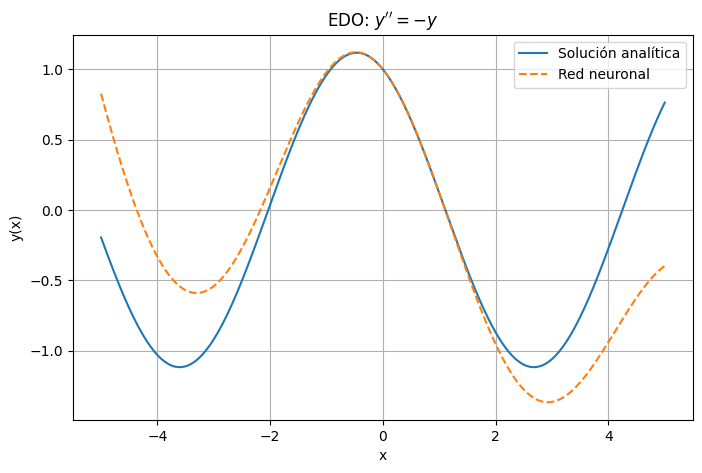

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    x_graf,
    y_analitica,
    label="Solución analítica"
)

plt.plot(
    x_graf,
    y_numerica,
    "--",
    label="Red neuronal"
)

plt.xlabel("x")
plt.ylabel("y(x)")
plt.title(r"EDO: $y''=-y$")
plt.legend()
plt.grid()
plt.show()

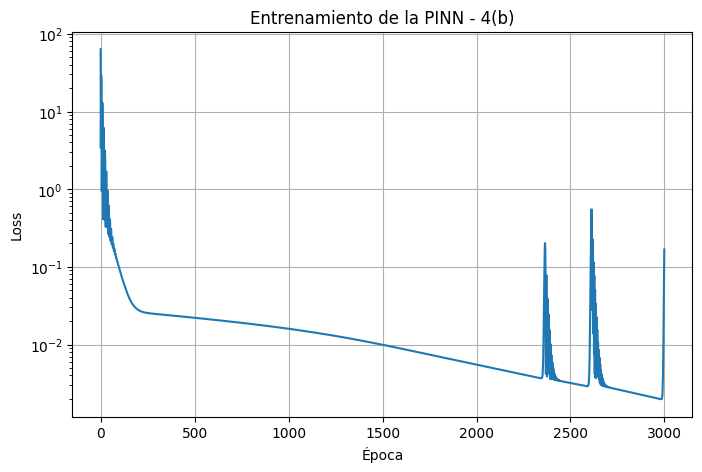

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(historia_4b)

plt.yscale("log")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Entrenamiento de la PINN - 4(b)")
plt.grid()
plt.show()